In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import os
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN, Ablation
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes/"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 512
train_loader, test_loader = initialize_dataloader(
    seed=42, root=maze_data_path, batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self, in_channels=4, num_classes=2, dropout=0.2):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, 64,  kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(64,          128, kernel_size=5, padding=2)
        self.conv3 = nn.Conv2d(128,         256, kernel_size=5, padding=2)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        # 28x28 -> pool -> 14x14 -> pool -> 7x7 -> pool -> 3x3
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28 -> 14
        x = self.pool(self.relu(self.conv2(x)))  # 14 -> 7
        x = self.pool(self.relu(self.conv3(x)))  # 7  -> 3
        x = torch.flatten(x, 1)
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)

def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20
    
    try:
        if model_cfg["model_type"] == "cnn":
            model = SimpleCNN()
            classifier = SimpleCNN()
        else:
            model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
            classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    except:
        model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
        classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps

def plot_activity_helper(activity, n, m, channel_idx, cmap='viridis'):
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity).item()
    vmax = torch.max(activity).item()
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step+1}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idxs,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    activity = torch.clamp(activity, max=2)
    plot_activity_helper(torch.mean(activity, axis=1), n, m, "all", cmap)
    
    if channel_idxs is None:
        channel_idxs = np.arange(activity.shape[1])
        
    for channel_idx in channel_idxs:
        channel_activity = activity[:, channel_idx]
        plot_activity_helper(channel_activity, n, m, channel_idx, cmap)

def plot(sample_indices,ablater=None):
    # Main plotting loop
    for plot_idx, sample_idx in enumerate(sample_indices):
        inp, label = inputs[sample_idx], labels[sample_idx]
        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
        activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                .detach().cpu()[0]  # shape (T, C)

        plot_channel_activity_solo(activity, channels_to_plot, n, m)

In [4]:
# ——— User‐set paths & names ———
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    # also used as epoch

# ReLU
# wandb_name = "earnest-planet-436"
# checkpoint = 800

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# wandb_name = "elated-wood-473"
# checkpoint = 170

# ReLU, with I->I recurrence
# wandb_name = "confused-haze-455"
# checkpoint = 1240

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)
classifier.eval()

/tmp/ipykernel_2037026/2310031928.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

SpatiallyEmbeddedClassifier(
  (rnn): SpatiallyEmbeddedRNN(
    (areas): ModuleList(
      (0): SpatiallyEmbeddedArea(
        (out_nonlinearity): Identity()
        (neuron_type_nonlinearity): ModuleList(
          (0-1): 2 x ReLU()
        )
        (convs): ModuleDict(
          (0->0): Sequential(
            (0): Conv2d(4, 8, kernel_size=(np.int64(5), np.int64(5)), stride=(1, 1), padding=(np.int64(2), np.int64(2)))
            (1): ReLU()
          )
          (0->1): Sequential(
            (0): Conv2d(4, 4, kernel_size=(np.int64(5), np.int64(5)), stride=(1, 1), padding=(np.int64(2), np.int64(2)))
            (1): ReLU()
          )
          (1->0): Sequential(
            (0): Conv2dRectify(8, 8, kernel_size=(np.int64(3), np.int64(3)), stride=(1, 1), padding=(np.int64(1), np.int64(1)))
            (1): ReLU()
          )
          (1->1): Sequential(
            (0): Conv2dRectify(8, 4, kernel_size=(np.int64(3), np.int64(3)), stride=(1, 1), padding=(np.int64(1), np.int64(1)))
 

In [7]:
classifier.to(device)
classifier.eval()

num_steps_to_try = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 35, 40, 50, 60, 70, 80, 90, 100]
num_steps_to_try = np.arange(1, 100)

# Choose a subset of the test_loader (e.g., first N batches)
subset_batches = 10
subset_data = []
subset_labels = []
count = 0
for x, labels in test_loader:
    subset_data.append(x)
    subset_labels.append(labels)
    count += 1
    if count >= subset_batches:
        break

subset_data = torch.cat(subset_data, dim=0)
subset_labels = torch.cat(subset_labels, dim=0)

# Initialize arrays with correct shapes for the subset
accuracies = np.zeros((len(num_steps_to_try), len(subset_labels)))
step_accuracies = np.zeros(len(num_steps_to_try))  # Overall accuracy per step

for step_idx, num_steps in enumerate(num_steps_to_try):
    correct = 0
    total = 0
    sample_idx = 0  # Track position in dataset

    with torch.no_grad():
        for start in range(0, len(subset_labels), batch_size):
            end = start + batch_size
            x = subset_data[start:end].to(device)
            labels = subset_labels[start:end].to(device)

            logits = classifier(x, num_steps=num_steps)

            _, predicted = torch.max(logits, 1)
            current_batch_size = labels.size(0)

            # Update overall accuracy
            total += current_batch_size
            correct += (predicted == labels).sum().item()

            # Store individual sample accuracies
            batch_correct = (predicted == labels).cpu().numpy()
            accuracies[step_idx, sample_idx:sample_idx + current_batch_size] = batch_correct
            sample_idx += current_batch_size

    # Calculate and store overall accuracy for this step
    step_accuracies[step_idx] = correct / total
    print(f"Steps {num_steps}: Accuracy = {step_accuracies[step_idx]:.4f}")

Steps 1: Accuracy = 0.4879
Steps 2: Accuracy = 0.5227
Steps 3: Accuracy = 0.5785
Steps 4: Accuracy = 0.6162
Steps 5: Accuracy = 0.6453
Steps 6: Accuracy = 0.6855
Steps 7: Accuracy = 0.7271
Steps 8: Accuracy = 0.7662
Steps 9: Accuracy = 0.8035
Steps 10: Accuracy = 0.8434
Steps 11: Accuracy = 0.8787
Steps 12: Accuracy = 0.9061
Steps 13: Accuracy = 0.9248
Steps 14: Accuracy = 0.9428
Steps 15: Accuracy = 0.9553
Steps 16: Accuracy = 0.9684
Steps 17: Accuracy = 0.9770
Steps 18: Accuracy = 0.9848
Steps 19: Accuracy = 0.9885
Steps 20: Accuracy = 0.9895
Steps 21: Accuracy = 0.9922
Steps 22: Accuracy = 0.9939
Steps 23: Accuracy = 0.9953
Steps 24: Accuracy = 0.9969
Steps 25: Accuracy = 0.9975
Steps 26: Accuracy = 0.9979
Steps 27: Accuracy = 0.9984
Steps 28: Accuracy = 0.9988
Steps 29: Accuracy = 0.9990
Steps 30: Accuracy = 0.9990
Steps 31: Accuracy = 0.9990
Steps 32: Accuracy = 0.9990
Steps 33: Accuracy = 0.9990
Steps 34: Accuracy = 0.9990
Steps 35: Accuracy = 0.9992
Steps 36: Accuracy = 0.9992
S

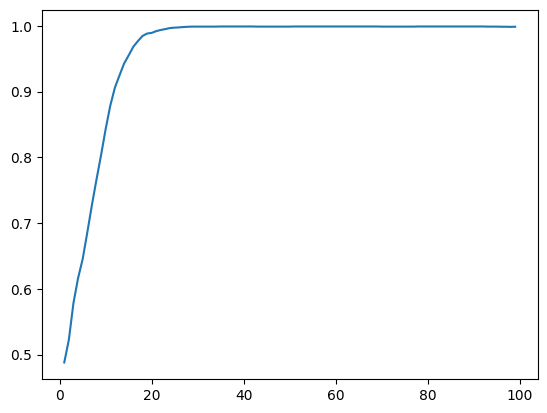

In [6]:
plt.plot(num_steps_to_try, accuracies.mean(axis=1))

In [ ]:
import pickle

a = {'num_steps': num_steps_to_try, "accuracies": accuracies}

with open('accuracies.pkl', 'wb') as handle:
    pickle.dump(a, handle)

In [5]:
import numpy as np

def cell_to_pixels(r, c):
    """Map a logical cell (r,c) to the 2×2 pixel block in a 48×48 grid."""
    return [(2*r + dr, 2*c + dc) for dr in (0, 1) for dc in (0, 1)]

def _base_u(cells=24, horiz=8, vert=4):
    """
    Build a 24×24 U‐maze open to the left, centered, with:
      - horizontal arms of length horiz+1
      - vertical connector of span vert+1
    """
    M = np.zeros((cells, cells), dtype=int)
    r0 = (cells - vert) // 2  # top arm row
    c0 = (cells - horiz) // 2 # leftmost column of arms

    M[r0,        c0 : c0 + horiz + 1] = 1
    M[r0 + vert, c0 : c0 + horiz + 1] = 1
    M[r0 : r0 + vert + 1, c0 + horiz] = 1
    return M

def _expand(base):
    """Expand 24×24 logical base to 48×48 pixels, returning (wall_pixels, endpoint_pixels)."""
    wall_cells = list(zip(*np.where(base == 1)))
    end_cells  = _logical_endpoints(base)
    wall_pixels     = [pix for cell in wall_cells for pix in cell_to_pixels(*cell)]
    endpoint_pixels = [pix for cell in end_cells  for pix in cell_to_pixels(*cell)]
    return wall_pixels, endpoint_pixels

# --- helpers ---
def _logical_endpoints(base):
    endpoints = []
    H, W = base.shape
    for r, c in zip(*np.where(base == 1)):
        cnt = sum(
            0 <= r+dr < H and 0 <= c+dc < W and base[r+dr, c+dc] == 1
            for dr, dc in ((1,0),(-1,0),(0,1),(0,-1))
        )
        if cnt == 1:
            endpoints.append((r, c))
    return endpoints

def _ordered_path_through_U(base, ends):
    """Return the unique ordered path (list of (r,c)) along the U from ends[0] to ends[1]."""
    assert len(ends) == 2, "U should have exactly two endpoints"
    H, W = base.shape
    def nbrs(r,c):
        for dr,dc in ((1,0),(-1,0),(0,1),(0,-1)):
            rr, cc = r+dr, c+dc
            if 0 <= rr < H and 0 <= cc < W and base[rr,cc] == 1:
                yield (rr, cc)

    start, goal = ends
    path = [start]
    prev = None
    cur = start
    # Walk along the single path (degree≤2 everywhere)
    while cur != goal:
        candidates = [n for n in nbrs(*cur) if n != prev]
        if not candidates:
            break  # should not happen for a valid U
        nxt = candidates[0] if len(candidates) == 1 else (
            candidates[0] if candidates[0] != prev else candidates[1]
        )
        path.append(nxt)
        prev, cur = cur, nxt
    return path

def _cells_to_pixels(cells):
    return [pix for (r, c) in cells for pix in cell_to_pixels(r, c)]

def _expand_with_preidentified_endpoints(base_post, end_cells_pre):
    wall_cells = [tuple(rc) for rc in np.argwhere(base_post == 1)]
    wall_pixels = _cells_to_pixels(wall_cells)
    endpoint_pixels = _cells_to_pixels(end_cells_pre)
    return wall_pixels, endpoint_pixels

def _ablate_u_segment(base, *, length=None, frac=None, seed=None, protect_endpoints=True):
    """
    Zero out a contiguous segment along the U path.
    Choose via absolute `length` (cells) or `frac` of total path.
    """
    base = base.copy()
    ends = _logical_endpoints(base)
    path = _ordered_path_through_U(base, ends)
    L = len(path)
    if L == 0:
        return base

    if length is None:
        assert frac is not None and 0 < frac <= 1, "Provide length or 0<frac<=1"
        length = max(1, int(round(frac * L)))
    length = max(1, min(length, L))

    rng = np.random.default_rng(seed)

    # Respect endpoint protection by limiting start index range
    start_min = 1 if protect_endpoints else 0
    start_max = (L - length - 1) if protect_endpoints else (L - length)
    if start_max < start_min:
        # If the requested segment is too large to avoid endpoints, shrink it
        length = max(1, (L - 2) if protect_endpoints else L)
        start_max = (L - length - 1) if protect_endpoints else (L - length)
        start_min = min(start_min, start_max)

    start_idx = int(rng.integers(start_min, start_max + 1)) if start_max >= start_min else start_min
    seg = path[start_idx:start_idx + length]

    for rc in seg:
        base[rc] = 0
    return base

# --- U maze builders: endpoints BEFORE ablation; ablate a contiguous U chunk ---
def _apply_u_ablation(base, ablate_u=None, seed=None, protect_endpoints=True):
    if ablate_u is None or ablate_u == 0:
        return base
    if isinstance(ablate_u, int):
        return _ablate_u_segment(base, length=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, float):
        return _ablate_u_segment(base, frac=ablate_u, seed=seed, protect_endpoints=protect_endpoints)
    if isinstance(ablate_u, dict):
        mode = ablate_u.get('mode', 'segment')
        if mode != 'segment':
            raise ValueError("Only 'segment' mode is supported for U-specific ablation.")
        length = ablate_u.get('length', None)
        frac   = ablate_u.get('frac', None)
        seed   = ablate_u.get('seed', seed)
        protect = ablate_u.get('protect_endpoints', protect_endpoints)
        return _ablate_u_segment(base, length=length, frac=frac, seed=seed, protect_endpoints=protect)
    raise ValueError("ablate_u must be int (length), float (frac), or dict")

def maze_right(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = _base_u(24, arm, vert)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_left(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.fliplr(_base_u(24, arm, vert))
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_up(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

def maze_down(arm=12, vert=4, ablate_u=None, seed=None, protect_endpoints=True):
    base = np.rot90(_base_u(24, arm, vert), k=-1)
    ends_pre = _logical_endpoints(base)
    base_post = _apply_u_ablation(base, ablate_u, seed, protect_endpoints)
    return _expand_with_preidentified_endpoints(base_post, ends_pre)

base_input = np.zeros((24,24))

In [6]:
def plot(inp, inp_np, just_walls, steps_to_plot, n_channels_to_plot, num_steps, correctness=None, excitatory=True, subtract_maze_activation=False, subtract_from_normal=False, ablate_all_but=False):
    # ----- Collect activity maps (ablations) -----
    activities = []

    if len(inp.shape) < 4:
        steps_given = num_steps
        inp_np = np.repeat(inp_np[None, ...], num_steps, axis=0)
    else:
        steps_given = None

    # ----- Normal (no ablation) activity -----
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=steps_given, ablater=None)
    normal_act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # (T, C, H, W)

    _, neuron_states, _ = model(just_walls.unsqueeze(0), num_steps=num_steps, ablater=None)
    normal_maze_act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # (T, C, H, W)

    # ----- Ablation activity -----
    for i in range(n_channels_to_plot):

        if ablate_all_but:
            neuron_ablation_config = {0: {j: "zero" for j in range(n_channels_to_plot) if j != i}}
        else:
            neuron_ablation_config = {0: {i: "zero"}}

        ablater = {
            step: {0: Ablation(neuron_ablation_config=neuron_ablation_config)}
            for step in range(num_steps)
        }

        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=steps_given, ablater=ablater)
        ablated_act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # (T, C, H, W)

        if subtract_from_normal:
            ablated_act = normal_act - ablated_act

        if subtract_maze_activation:
            _, neuron_states, _ = model(just_walls.unsqueeze(0), num_steps=num_steps, ablater=ablater)
            ablated_maze_act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # (T, C, H, W)

            if subtract_from_normal:
                ablated_act = (normal_act - ablated_act) - (normal_maze_act - ablated_maze_act)
            else:
                ablated_act = ablated_act - ablated_maze_act

        ablated_act = ablated_act.mean(dim=1).numpy()  # (T, H, W)
        activities.append(ablated_act)

    if subtract_maze_activation:
        normal_act = normal_act - normal_maze_act

    normal_act = normal_act.mean(dim=1).detach().cpu().numpy()  # (T, H, W) -> numpy

    # ----- Plot grid -----
    n_rows_acts  = len(activities)            # ablated activity rows
    n_cols       = len(steps_to_plot)
    n_rows_total = n_rows_acts + 2            # Input + Normal + Ablated rows

    fig, axes = plt.subplots(n_rows_total, n_cols, figsize=(3*n_cols, 3*n_rows_total), squeeze=False)

    # ---- Top row: Input (grayscale + red overlay) ----
    bg_stack = inp_np[steps_to_plot, 0]
    bg_vmin, bg_vmax = np.nanmin(bg_stack), np.nanmax(bg_stack)

    for col_idx, step_idx in enumerate(steps_to_plot):
        ax = axes[0, col_idx]
        bg   = inp_np[step_idx, 0]
        over = inp_np[step_idx, -1]

        ax.imshow(bg, cmap='gray', vmin=bg_vmin, vmax=bg_vmax, interpolation='none')

        over_norm = over.astype(float)
        vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
        over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

        rgba = np.zeros((*over_norm.shape, 4), dtype=float)
        rgba[..., 0] = 1.0
        rgba[..., 3] = over_norm * 0.85
        ax.imshow(rgba, interpolation='none')

        ax.axis('off')
        ax.set_title(f"Step {step_idx}", fontsize=20)

    # Label the input row
    axes[0, 0].annotate("Input", xy=(-0.25, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=20, fontweight='bold',
                        annotation_clip=False)

    # ---- NEW second row: Normal (no ablation) activity ----
    norm_stack = normal_act[steps_to_plot]              # (n_cols, H, W)
    nvmin, nvmax = np.nanmin(norm_stack), np.nanmax(norm_stack)

    for col_idx, step_idx in enumerate(steps_to_plot):
        ax = axes[1, col_idx]
        ax.imshow(normal_act[step_idx], vmin=nvmin, vmax=nvmax, interpolation='none')
        ax.axis('off')

    # Label the normal row
    axes[1, 0].annotate("None", xy=(-0.25, 0.5), xycoords='axes fraction',
                        ha='right', va='center', fontsize=20, fontweight='bold',
                        annotation_clip=False)

    # ---- Ablated activity rows (shifted down by +2) ----
    for row_idx in range(n_rows_acts):
        row_stack = activities[row_idx][steps_to_plot]
        vmin, vmax = np.nanmin(row_stack), np.nanmax(row_stack)

        for col_idx, step_idx in enumerate(steps_to_plot):
            ax = axes[row_idx + 2, col_idx]  # +2: skip Input + Normal
            ax.imshow(activities[row_idx][step_idx], vmin=vmin, vmax=vmax, interpolation='none')
            ax.axis('off')

        if correctness is not None:
            if correctness[row_idx+1]:
                correct = "Correct"
            else:
                correct = "Incorrect"
        else:
            correct = ""

        axes[row_idx + 2, 0].annotate(f"Channel {row_idx}, {correct}",
                                    xy=(-0.25, 0.5), xycoords='axes fraction',
                                    ha='right', va='center', fontsize=20, fontweight='bold',
                                    annotation_clip=False)

    plt.tight_layout()
    plt.subplots_adjust(left=0.12)  # room for left labels
    if ablate_all_but:
        fig.supylabel("Channel not ablated", x=0.06, fontsize=20, fontweight='bold')
    else:
        fig.supylabel("Channel ablated", x=0.06, fontsize=20, fontweight='bold')
    plt.show()


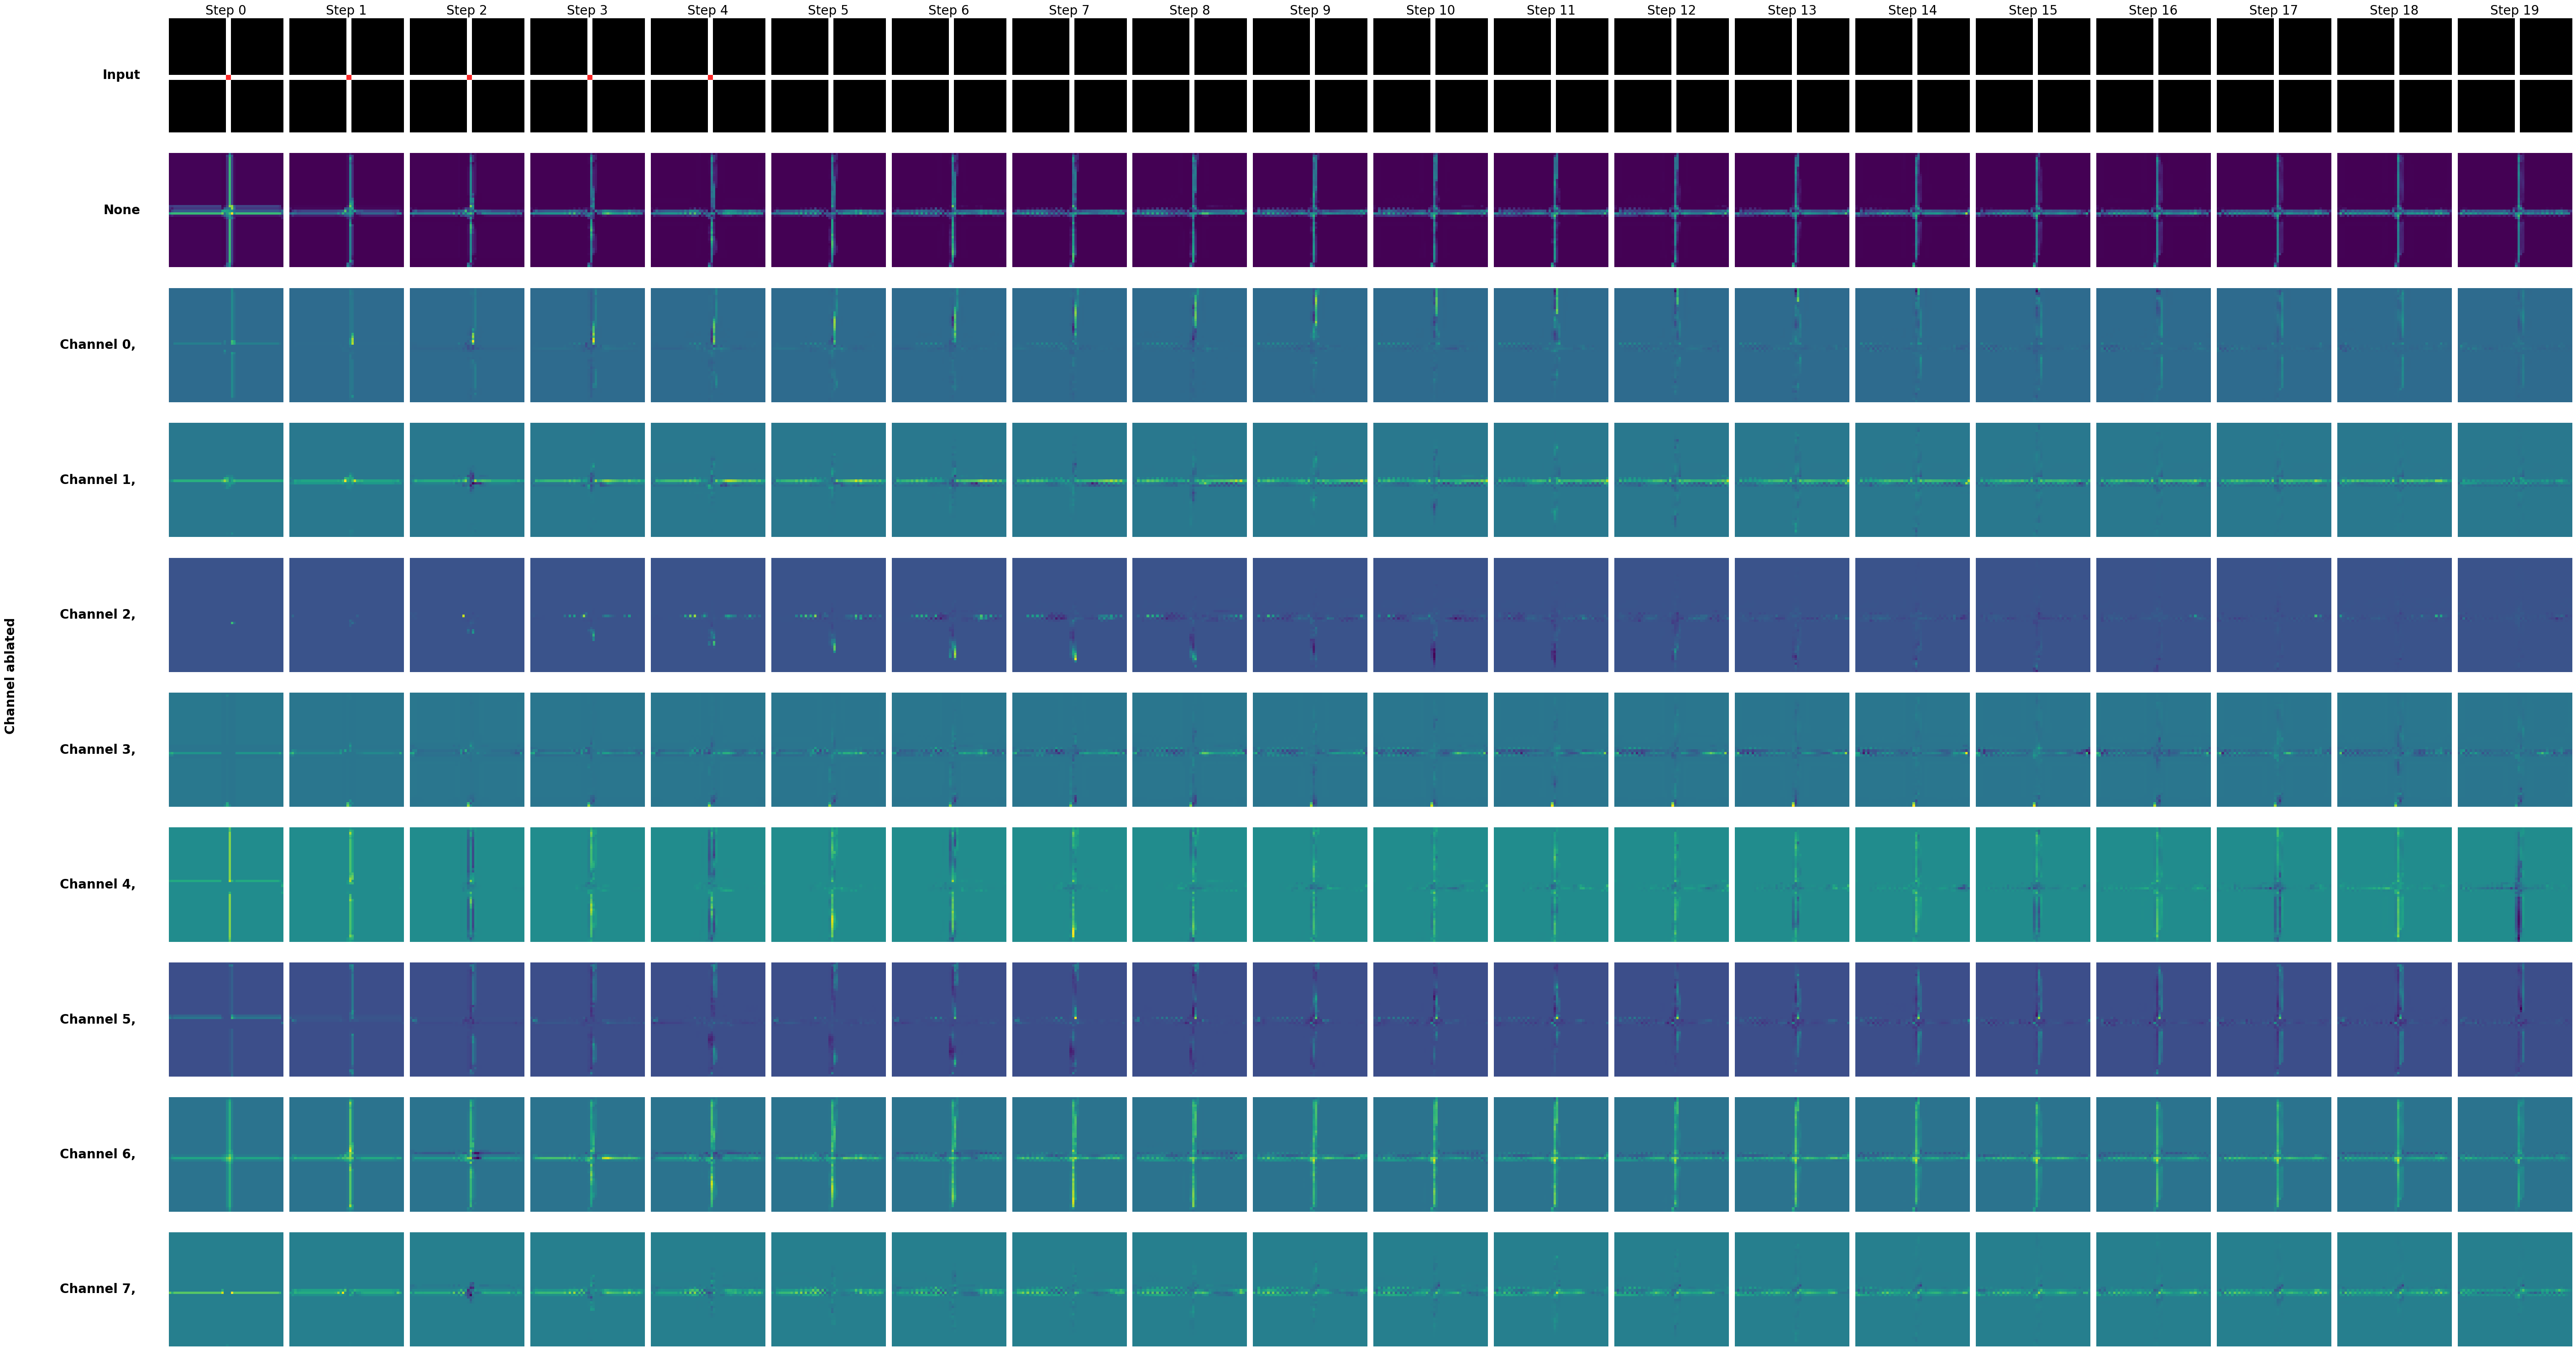

In [13]:
walls = base_input.copy()
corridor_idx = 12
walls[corridor_idx, :] = 1
walls[:, corridor_idx] = 1
walls = walls.repeat(2, axis=0).repeat(2, axis=1)
walls = np.stack([walls, walls, walls], axis=0)   # shape (3, 48, 48)

points = base_input.copy()
points[12, 12] = 1
points = points.repeat(2, axis=0).repeat(2, axis=1)
points = points[np.newaxis, ...]
inp = np.concatenate([walls, points], axis=0)
inp = torch.tensor(inp, dtype=torch.float32)
# plt.imshow(inp[0] + inp[3]*2)
# plt.show()

# ----- Build input tensor (T, C, H, W) -----
num_steps = 20
num_input_steps = 5

C = np.concatenate([walls, points], axis=0)              # (4, 48, 48)
C = np.repeat(C[None, ...], num_input_steps, axis=0)     # (num_input_steps, 4, 48, 48)

empty_points = np.zeros_like(points)
just_walls = np.concatenate([walls, empty_points], axis=0)        # (4, 48, 48)
D = np.repeat(just_walls[None, ...], num_steps - num_input_steps, axis=0)
just_walls = torch.as_tensor(just_walls, dtype=torch.float32)

inp_np = np.concatenate([C, D], axis=0)                  # (num_steps, 4, 48, 48)
inp = torch.as_tensor(inp_np, dtype=torch.float32)

steps_to_plot = np.arange(0, num_steps)
n_channels_to_plot = 8

# When setting subtract_from_normal=True, positive activity is the activity that would be propagating if not for the ablation
# If ablate_all_but=True, positive activity can only be probagated by the non ablated channel

plot(inp, inp_np, just_walls, steps_to_plot, n_channels_to_plot, num_steps, excitatory=True, subtract_maze_activation=False, subtract_from_normal=True, ablate_all_but=False)

# Checking if activity propagates all the way

In [ ]:
points = base_input.copy()
points[12, 12] = 1

points = points.repeat(2, axis=0).repeat(2, axis=1)
points = points[np.newaxis, ...]

threshold = 0.1

prop_directions = {i:[] for i in range(8)}

for i in range(8):
    neuron_ablation_config = {0: {i: "zero"}}
    ablater = {i:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for i in range(num_steps)}

    for fn in (left, right, up, down, down_right, down_left, up_right, up_left):
        rows, cols = zip(*fn())
        walls = base_input.copy()
        walls = walls.repeat(2, axis=0).repeat(2, axis=1)
        walls[rows, cols] = 1
        walls = np.stack([walls, walls, walls], axis=0)
        inp = np.concatenate([walls, points], axis=0)
        inp = torch.tensor(inp, dtype=torch.float32)

        _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
        activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                .detach().cpu()[0]  # shape (T, C)
        
        # plot_channel_activity_solo(activity, channels_to_plot, n, m)
        mean_activity = torch.mean(activity, axis=1)

        #cut out center
        mean_activity[:, 18:30, 18:30] = 0
        activity_change = (mean_activity[5:] > threshold).sum(dim=(1, 2)).max().item() - (mean_activity[1] > threshold).sum().item()
        if activity_change < 2:
            prop_directions[i].append(fn.__name__)
    

# Checking if mazes can be solved

In [12]:
def plot_jawn(arm, vert, ablation_channel, fn, num_steps):
    neuron_ablation_config = {0: {ablation_channel: "zero"}}
    ablater = {j:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for j in range(num_steps)}

    # predesigned input
    wall_pixels, input_pixels = fn(arm=arm, vert=vert)
    wall_rows, wall_cols = zip(*wall_pixels)
    input_rows, input_cols = zip(*input_pixels)
    walls = base_input.copy()
    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
    walls[wall_rows, wall_cols] = 1
    walls = np.stack([walls, walls, walls], axis=0)
    points = base_input.copy()
    points = points.repeat(2, axis=0).repeat(2, axis=1)
    points[input_rows, input_cols] = 1
    points = points[np.newaxis, ...]

    #combine
    inp = np.concatenate([walls, points], axis=0)
    inp = torch.tensor(inp, dtype=torch.float32)

    pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=20, ablater=ablater, return_activations=True)

    correct = (pred.argmax(dim=1).item() == 1)
    print(correct)
    if not correct:
        prop_directions[i].append(fn.__name__)
    
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # shape (T, C)
    plot_channel_activity_solo(activity, channels_to_plot, n, m)


In [ ]:
threshold = 0.1

n_channels_to_plot = 0

for arm in [12]:
    for vert in [5]:
        prop_directions = {i:[] for i in range(8)}
        for i in range(9):
            if i == 0:
                ablater = None
            else:
                i = i - 1
                neuron_ablation_config = {0: {i: "zero"}}
                ablater = {j:  {0: Ablation(neuron_ablation_config=neuron_ablation_config)} for j in range(num_steps)}

            for fn in (maze_left, maze_right, maze_up, maze_down):

                print(i, fn.__name__)

                # predesigned input
                wall_pixels, input_pixels = fn(arm=arm, vert=vert)
                wall_rows, wall_cols = zip(*wall_pixels)
                input_rows, input_cols = zip(*input_pixels)
                walls = base_input.copy()
                walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                walls[wall_rows, wall_cols] = 1
                walls = np.stack([walls, walls, walls], axis=0)
                points = base_input.copy()
                points = points.repeat(2, axis=0).repeat(2, axis=1)
                points[input_rows, input_cols] = 1
                points = points[np.newaxis, ...]

                #combine
                inp = np.concatenate([walls, points], axis=0)
                inp = torch.tensor(inp, dtype=torch.float32)

                # _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater)
                # activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
                #         .detach().cpu()[0]  # shape (T, C)
                # plot_channel_activity_solo(activity, channels_to_plot, n, m)

                pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=20, ablater=ablater, return_activations=True)

                correct = (pred.argmax(dim=1).item() == 1)
                print(correct)
                if not correct:
                    prop_directions[i].append(fn.__name__)
                
                # activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1).detach().cpu()[0]  # shape (T, C)
                # plot_channel_activity_solo(activity, channels_to_plot, n, m)

        print(arm, vert) 
        print(prop_directions)
        
# {0: [], 1: [], 2: ['maze_down'], 3: [], 4: [], 5: [], 6: [], 7: ['maze_up']}
# {0: [], 1: [], 2: ['maze_down'], 3: ['maze_left', 'maze_up'], 4: ['maze_left'], 5: [], 6: ['maze_right'], 7: ['maze_up']}



In [ ]:
neuron_ablation_config = {0: {2: "zero"}}

ablater = {
    step: {0: Ablation(neuron_ablation_config=neuron_ablation_config)}
    for step in range(30)
}
        
steps_to_plot = np.arange(15, 25)
accuracies = []

for num_steps in steps_to_plot:
    print(num_steps)
    num_correct = 0
    total = 0
    for arm in [4,5,6,7,8,9,10,11,12,13,14]:
        for vert in [4,5,6,7,8,9,10,11,12,13,14]:
            for fn in (maze_left, maze_right, maze_up, maze_down):

                # predesigned input
                wall_pixels, input_pixels = fn(arm=arm, vert=vert)
                wall_rows, wall_cols = zip(*wall_pixels)
                input_rows, input_cols = zip(*input_pixels)
                walls = base_input.copy()
                walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                walls[wall_rows, wall_cols] = 1
                walls = np.stack([walls, walls, walls], axis=0)
                points = base_input.copy()
                points = points.repeat(2, axis=0).repeat(2, axis=1)
                points[input_rows, input_cols] = 1
                points = points[np.newaxis, ...]

                #combine
                inp_np = np.concatenate([walls, points], axis=0)
                inp = torch.tensor(inp_np, dtype=torch.float32)

                if "CNN" in classifier.__class__.__name__:
                    pred = classifier(inp.unsqueeze(0))
                else:
                    pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=num_steps, ablater=None, return_activations=True)


                correct = (pred.argmax(dim=1).item() == 1)
                if correct: num_correct += 1
                total += 1

    accuracies.append(num_correct/total)
    print(num_correct/total)

Text(0.5, 0, 'Step')

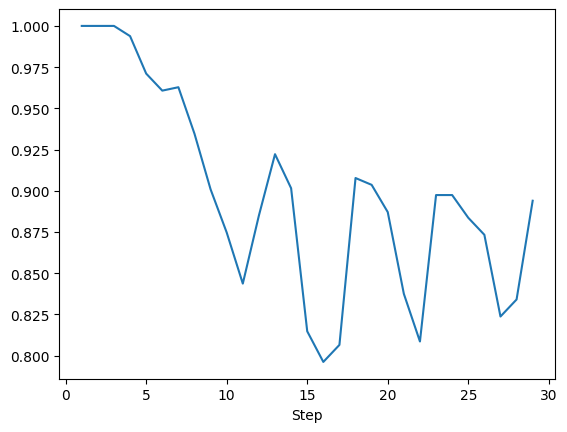

In [27]:
plt.plot(steps_to_plot, accuracies)
plt.xlabel("Step")

In [10]:
steps_to_plot = np.arange(15, 25)
accuracies = []

for num_steps in steps_to_plot:
    print(num_steps)
    num_correct = 0
    total = 0
    for arm in [4,5,6,7,8,9,10,11,12,13,14]:
        for vert in [8,9,10,11,12,13,14]:
            for ablate_u in [4, 5, 6]:
                for fn in (maze_left, maze_right, maze_up, maze_down):

                    # predesigned input
                    wall_pixels, input_pixels = fn(arm=arm, vert=vert, ablate_u=ablate_u, seed=1)
                    wall_rows, wall_cols = zip(*wall_pixels)
                    input_rows, input_cols = zip(*input_pixels)
                    walls = base_input.copy()
                    walls = walls.repeat(2, axis=0).repeat(2, axis=1)
                    walls[wall_rows, wall_cols] = 1
                    walls = np.stack([walls, walls, walls], axis=0)
                    points = base_input.copy()
                    points = points.repeat(2, axis=0).repeat(2, axis=1)
                    points[input_rows, input_cols] = 1
                    points = points[np.newaxis, ...]

                    #combine
                    inp_np = np.concatenate([walls, points], axis=0)
                    inp = torch.tensor(inp_np, dtype=torch.float32)

                    # plt.imshow(inp_np[0] + inp_np[-1]*2)
                    # plt.show()

                    if "CNN" in classifier.__class__.__name__:
                        pred = classifier(inp.unsqueeze(0))
                    else:
                        pred, outs, neuron_states, fbs = classifier(inp.unsqueeze(0), num_steps=num_steps, ablater=ablater, return_activations=True)

                    correct = (pred.argmax(dim=1).item() == 0)
                    if correct: num_correct += 1
                    total += 1
                    
    accuracies.append(num_correct/total)
    print(num_correct/total)

15
1.0
16
1.0
17
1.0
18
1.0
19
1.0
20
1.0
21
1.0
22
1.0
23
1.0
24
1.0


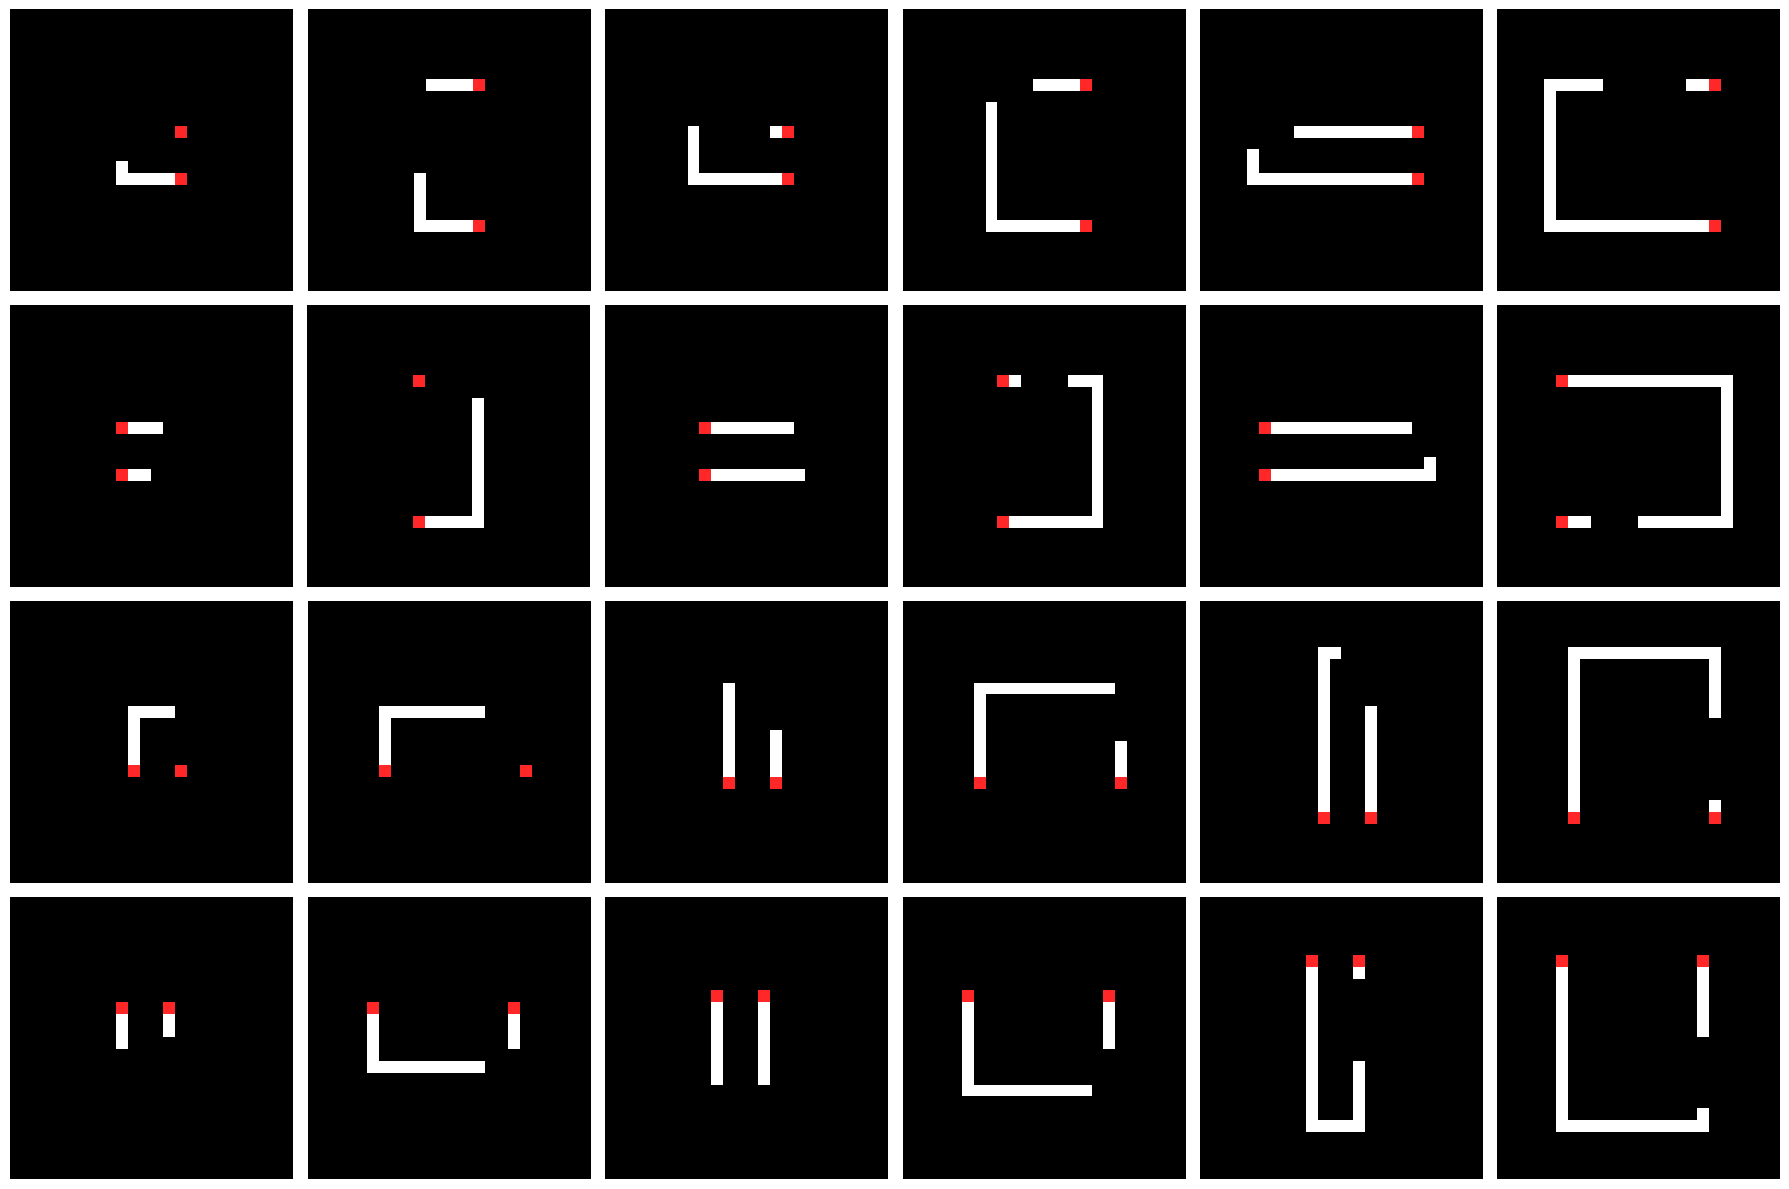

In [102]:
# Plot all maze variants in a big grid

arms = [5, 8, 14]
verts = [4, 12]
maze_fns = [maze_left, maze_right, maze_up, maze_down]
n_rows = len(maze_fns)
n_cols = len(arms) * len(verts)

fig, axs = plt.subplots(n_rows, n_cols, figsize=(3*n_cols, 3*n_rows), squeeze=False)

col_idx = 0
for arm in arms:
    for vert in verts:
        for row_idx, fn in enumerate(maze_fns):
            # predesigned input
            wall_pixels, input_pixels = fn(arm=arm, vert=vert, ablate_u=random.randint(4, 8))
            wall_rows, wall_cols = zip(*wall_pixels)
            input_rows, input_cols = zip(*input_pixels)
            walls = base_input.copy()
            walls = walls.repeat(2, axis=0).repeat(2, axis=1)
            walls[wall_rows, wall_cols] = 1
            walls = np.stack([walls, walls, walls], axis=0)
            points = base_input.copy()
            points = points.repeat(2, axis=0).repeat(2, axis=1)
            points[input_rows, input_cols] = 1
            points = points[np.newaxis, ...]

            # combine
            inp_np = np.concatenate([walls, points], axis=0)
            inp = torch.tensor(inp_np, dtype=torch.float32)

            bg   = inp_np[0]
            over = inp_np[-1]

            ax = axs[row_idx, col_idx]
            ax.imshow(bg, cmap='gray', vmin=bg_vmin, vmax=bg_vmax, interpolation='none')

            over_norm = over.astype(float)
            vmax_o, vmin_o = np.nanmax(over_norm), np.nanmin(over_norm)
            over_norm = (over_norm - vmin_o) / (vmax_o - vmin_o) if vmax_o > vmin_o else np.zeros_like(over_norm)

            rgba = np.zeros((*over_norm.shape, 4), dtype=float)
            rgba[..., 0] = 1.0
            rgba[..., 3] = over_norm * 0.85
            ax.imshow(rgba, interpolation='none')

            ax.axis('off')
        col_idx += 1

plt.tight_layout()
plt.show()

# Checking Receptiveness to Wall Patterns

In [ ]:
import numpy as np
import torch

# ----- shape makers -----
def make_L(vert_len=5, horiz_len=5, thickness=1):
    """
    L pointing down+right, anchored at top-left of the pattern.
    thickness=1 gives a 1-pixel wide L; increase for thicker strokes.
    """
    H, W = vert_len, horiz_len
    pat = np.zeros((H, W), dtype=np.uint8)
    pat[:, :thickness] = 1                # vertical bar (down)
    pat[:thickness, :W] = 1               # horizontal bar (right)
    return pat

def make_line(length=7, orientation='h', thickness=1):
    """
    orientation: 'h' (horizontal) or 'v' (vertical)
    """
    if orientation == 'h':
        pat = np.zeros((thickness, length), dtype=np.uint8)
        pat[:] = 1
    elif orientation == 'v':
        pat = np.zeros((length, thickness), dtype=np.uint8)
        pat[:] = 1
    else:
        raise ValueError("orientation must be 'h' or 'v'")
    return pat

# ----- utilities -----
def rotate_pattern(pat, k=0):
    """Rotate pattern by 90*k degrees."""
    return np.rot90(pat, k=k)

def place_pattern_on_grid(pat, grid_size=24, rng=None, pos=None):
    """
    Place binary pattern 'pat' on a zero grid. If pos is None, choose a random
    top-left (row, col) so the pattern fits fully inside.
    Returns np.uint8 (0/1) array of shape (grid_size, grid_size) and (row, col).
    """
    if rng is None:
        rng = np.random.default_rng()
    H, W = pat.shape
    if H > grid_size or W > grid_size:
        raise ValueError("Pattern larger than grid.")
    if pos is None:
        r = rng.integers(0, grid_size - H + 1)
        c = rng.integers(0, grid_size - W + 1)
    else:
        r, c = pos
        if not (0 <= r <= grid_size - H and 0 <= c <= grid_size - W):
            raise ValueError("Provided 'pos' places pattern out of bounds.")
    grid = np.zeros((grid_size, grid_size), dtype=np.uint8)
    grid[r:r+H, c:c+W] |= pat
    return grid, (r, c)

def generate_batch(patterns, n=32, grid_size=24, rotations=(0,), seed=None, device="cpu", return_positions=False):
    """
    patterns: a single np.ndarray pattern OR a list/tuple of patterns (binary 0/1).
    rotations: allowed 90° rotations to randomly sample from (e.g., (0,1,2,3)).
    Returns torch.float32 tensor of shape (n, grid_size, grid_size) with 0/1 values.
    """
    rng = np.random.default_rng(seed)
    if isinstance(patterns, (list, tuple)):
        pats = list(patterns)
    else:
        pats = [patterns]

    xs = []
    poss = []
    for _ in range(n):
        pat = pats[rng.integers(0, len(pats))]
        k = rotations[rng.integers(0, len(rotations))]
        pat_k = rotate_pattern(pat, k=k) if k else pat
        arr, pos = place_pattern_on_grid(pat_k, grid_size=grid_size, rng=rng)
        xs.append(arr)
        poss.append(pos)

    x = torch.from_numpy(np.stack(xs)).to(torch.float32).to(device)
    if return_positions:
        return x, poss
    return x

# ----- examples -----
if __name__ == "__main__":
    # Example 1: L shape (down+right), length 6×8, make 16 samples with all 4 rotations
    L = make_L(vert_len=6, horiz_len=6, thickness=1)
    batch_L = generate_batch(L, n=16, rotations=([3]), seed=0)   # (16, 28, 28)
    plt.imshow(batch_L[4])
    plt.show()

    # Example 2: horizontal line of length 9
    line_h = make_line(length=6, orientation='h')
    batch_line = generate_batch(line_h, n=16, seed=1)                # (16, 28, 28)
    plt.imshow(batch_line[4])
    plt.show()

    # Example 3: mix shapes in one batch
    line_v = make_line(length=7, orientation='v')
    mixed = generate_batch([L, line_h, line_v], n=24, rotations=(0,1,2,3), seed=2)
    plt.imshow(mixed[5])
    plt.show()

    # If you need the top-left placement for labels/debug:
    batch_with_pos, positions = generate_batch(L, n=8, rotations=(0,1,2,3), seed=3, return_positions=True)
    print(batch_with_pos.shape, positions[:3])


In [ ]:
model.to(device)
activations = np.zeros((6, 8))

for len_idx, length in enumerate([2, 4, 6, 8, 10, 12]):
    line_h = make_line(length=length, orientation='v')
    walls = np.array(generate_batch(line_h, n=1024, seed=4))
    walls = walls.repeat(2, axis=1).repeat(2, axis=2)
    points = np.zeros_like(walls)
    points = points[:, np.newaxis, ...]
    walls = np.stack([walls, walls, walls], axis=1)
    inp = np.concatenate([walls, points], axis=1)
    inp = torch.tensor(inp, dtype=torch.float32).to(device)

    _, neuron_states, _ = model(inp, num_steps=3, ablater=None)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu().numpy()  # shape (T, C)
    
    # Compute the sum of all neuron activities and divide by the number of active neurons (nonzero entries)
    total_activity = np.sum(activity, axis=(0, 1, 3, 4))
    num_active_neurons = np.count_nonzero(activity, axis=(0, 1, 3, 4))
    # Avoid division by zero
    activations[len_idx] = np.where(num_active_neurons > 0, total_activity / num_active_neurons, 0)

In [ ]:
for channel_idx in range(8):
    plt.plot([2, 4, 6, 8, 10, 12], activations[:, channel_idx], label=f"Channel {channel_idx}")
plt.xlabel("length")
plt.ylabel("sum activity / num active neurons")
plt.legend()
plt.show()

# Receptiveness + Start Input

In [ ]:
import numpy as np
from collections import deque
from typing import Tuple, Dict

# ----- Globals -----
N = 24
CENTER = (N // 2, N // 2)  # (row, col)

# ----- Maze primitives (walls=0, corridors=1) -----
def blank_maze(n: int = N) -> np.ndarray:
    return np.zeros((n, n), dtype=np.uint8)

def carve_line(maze: np.ndarray, r1: int, c1: int, r2: int, c2: int) -> None:
    """Axis-aligned corridor carving (set to 1)."""
    if r1 == r2:
        r = r1
        c_lo, c_hi = sorted([c1, c2])
        maze[r, c_lo:c_hi+1] = 1
    elif c1 == c2:
        c = c1
        r_lo, r_hi = sorted([r1, r2])
        maze[r_lo:r_hi+1, c] = 1
    else:
        raise ValueError("Only axis-aligned lines supported.")

def place_start(mask: np.ndarray, rc: Tuple[int,int]) -> None:
    r, c = rc
    mask[r, c] = 1

# ----- Base layouts -----
def base_cross(arm_len: int = 10) -> np.ndarray:
    maze = blank_maze()
    r0, c0 = CENTER
    carve_line(maze, r0, c0 - arm_len, r0, c0 + arm_len)   # horizontal
    carve_line(maze, r0 - arm_len, c0, r0 + arm_len, c0)   # vertical
    return maze

def base_corner(arm_len_h: int = 10, arm_len_v: int = 10, turn: str = "left") -> np.ndarray:
    """
    Corner at CENTER. turn='left' makes an ┘ shape (down then left),
    turn='right' makes an └ shape (down then right).
    """
    maze = blank_maze()
    r0, c0 = CENTER
    carve_line(maze, r0, c0, r0 + arm_len_v, c0)              # vertical (down)
    if turn == "left":
        carve_line(maze, r0, c0 - arm_len_h, r0, c0)          # left from center
    elif turn == "right":
        carve_line(maze, r0, c0, r0, c0 + arm_len_h)          # right from center
    else:
        raise ValueError("turn ∈ {'left','right'}")
    return maze

# ----- Position pickers -----
def pick_cross_pos(maze: np.ndarray, d: int, direction: str) -> Tuple[int,int]:
    r0, c0 = CENTER
    if direction == "up":    rc = (r0 - d, c0)
    elif direction == "down":rc = (r0 + d, c0)
    elif direction == "left":rc = (r0, c0 - d)
    elif direction == "right":rc = (r0, c0 + d)
    else: raise ValueError("direction ∈ {'up','down','left','right'}")
    r, c = rc
    if not (0 <= r < N and 0 <= c < N) or maze[r, c] != 1:
        raise ValueError(f"Invalid start at d={d}, dir={direction}")
    return rc

def pick_corner_pos(maze: np.ndarray, d: int, where: str, turn: str) -> Tuple[int,int]:
    r0, c0 = CENTER
    if where == "pre_corner":
        rc = (r0 + d, c0)  # down the incoming arm
    elif where == "around_corner":
        rc = (r0, c0 - d) if turn == "left" else (r0, c0 + d)
    else:
        raise ValueError("where ∈ {'pre_corner','around_corner'}")
    r, c = rc
    if not (0 <= r < N and 0 <= c < N) or maze[r, c] != 1:
        raise ValueError(f"Invalid start at d={d}, where={where}, turn={turn}")
    return rc

# ----- Control: break connectivity toward CENTER -----
def add_barrier_toward_center(maze: np.ndarray, start_rc: Tuple[int,int]) -> None:
    """Zero the cell one step from CENTER toward start_rc to break the corridor."""
    br, bc = CENTER
    dr = np.sign(start_rc[0] - br)
    dc = np.sign(start_rc[1] - bc)
    pr, pc = br + dr, bc + dc
    if 0 <= pr < N and 0 <= pc < N:
        maze[pr, pc] = 0
    maze[br, bc] = 1  # keep center open

# ----- Builders (return: maze, start_mask) -----
def build_cross_condition(d: int, direction: str, unreachable: bool=False) -> Tuple[np.ndarray, np.ndarray]:
    maze = base_cross()
    start_mask = np.zeros_like(maze)
    s_rc = pick_cross_pos(maze, d=d, direction=direction)
    if unreachable:
        add_barrier_toward_center(maze, s_rc)
    place_start(start_mask, s_rc)
    return maze, start_mask

def build_corner_condition(d: int, turn: str, where: str, unreachable: bool=False) -> Tuple[np.ndarray, np.ndarray]:
    maze = base_corner(turn=turn)
    start_mask = np.zeros_like(maze)
    s_rc = pick_corner_pos(maze, d=d, where=where, turn=turn)
    if unreachable:
        add_barrier_toward_center(maze, s_rc)
    place_start(start_mask, s_rc)
    return maze, start_mask

def build_baseline(layout: str="cross") -> Tuple[np.ndarray, np.ndarray]:
    """Baseline: same corridors, no start."""
    if layout == "cross": maze = base_cross()
    elif layout == "corner_left": maze = base_corner(turn="left")
    elif layout == "corner_right": maze = base_corner(turn="right")
    else: raise ValueError("layout ∈ {'cross','corner_left','corner_right'}")
    return maze, np.zeros_like(maze)

# ----- Stimulus set convenience -----
def make_stimulus_set() -> Dict[str, Tuple[np.ndarray, np.ndarray]]:
    stimuli = {}
    for d in (4, 6, 10):
        for direction in ("up","down","left","right"):
            name = f"cross_d{d}_{direction}"
            stimuli[name] = build_cross_condition(d, direction, unreachable=False)
            stimuli[name + "_blocked"] = build_cross_condition(d, direction, unreachable=True)
        for turn in ("left","right"):
            for where in ("pre_corner","around_corner"):
                name = f"corner_{turn}_{where}_d{d}"
                stimuli[name] = build_corner_condition(d, turn, where, unreachable=False)
                stimuli[name + "_blocked"] = build_corner_condition(d, turn, where, unreachable=True)

    stimuli["cross_baseline"] = build_baseline("cross")
    stimuli["corner_left_baseline"]  = build_baseline("corner_left")
    stimuli["corner_right_baseline"] = build_baseline("corner_right")
    return stimuli


In [ ]:
import numpy as np
import pandas as pd
import re
from typing import Callable, Dict, Tuple, List, Optional

# Type of your eval function:
#   eval_fn(maze: np.ndarray, start_mask: np.ndarray, T: int, channel: int) -> np.ndarray (shape [T])
EvalFn = Callable[[np.ndarray, np.ndarray, int, int], np.ndarray]

# ---- Utilities ----
def _layout_of(name: str) -> str:
    """Map a condition name to its baseline layout key."""
    if name.startswith("cross"):
        return "cross"
    if name.startswith("corner_left"):
        return "corner_left"
    if name.startswith("corner_right"):
        return "corner_right"
    if name.startswith("corner_"):
        # Fallback for any other corner_* names
        if "_left_" in name:  return "corner_left"
        if "_right_" in name: return "corner_right"
        return "corner_left"  # default; adjust if you add other variants
    raise ValueError(f"Cannot infer layout for condition name: {name}")

def _baseline_for(layout: str) -> str:
    return {
        "cross": "cross_baseline",
        "corner_left": "corner_left_baseline",
        "corner_right": "corner_right_baseline",
    }[layout]

def _parse_metadata(name: str) -> dict:
    """
    Parse names produced by make_stimulus_set(), e.g.:
      cross_d8_left
      cross_d12_right_blocked
      corner_left_pre_corner_d4
      corner_right_around_corner_d8_blocked
    """
    meta = dict(family=None, d=None, direction=None, turn=None, where=None, blocked=False)

    blocked = name.endswith("_blocked")
    base = name[:-8] if blocked else name
    meta["blocked"] = blocked

    if base.startswith("cross"):
        meta["family"] = "cross"
        # distance like _d8
        m = re.search(r"_d(\d+)\b", base)
        meta["d"] = int(m.group(1)) if m else None
        # direction token
        for d in ("up", "down", "left", "right"):
            if re.search(fr"_{d}\b", base):
                meta["direction"] = d
                break

    elif base.startswith("corner"):
        meta["family"] = "corner"
        # left/right
        if "_left_" in base:
            meta["turn"] = "left"
        elif "_right_" in base:
            meta["turn"] = "right"
        # where
        if "pre_corner" in base:
            meta["where"] = "pre_corner"
        elif "around_corner" in base:
            meta["where"] = "around_corner"
        # distance
        m = re.search(r"_d(\d+)\b", base)
        meta["d"] = int(m.group(1)) if m else None

    else:
        raise ValueError(f"Unrecognized condition name: {name}")

    return meta

# ---- Core experiment ----
def run_start_modulation_experiment(
    eval_fn: EvalFn,
    *,
    T: int,
    channel: int,
    t_measure: Optional[int] = None,   # default: last step
    avg_last_k: Optional[int] = None,  # alternative: average last k steps
    include_time_series: bool = False
) -> pd.DataFrame:
    """
    Runs the experiment over the stimulus set and returns a tidy DataFrame with:
      [condition, family, layout, d, direction, turn, where, blocked, 
       r_baseline_at_t, r_cond_at_t, delta_at_t, (optionally) traces]
    """
    stimuli = make_stimulus_set()  # from previous snippet
    # cache baselines (one run each)
    baseline_cache: Dict[str, np.ndarray] = {}
    for layout_name in ("cross_baseline", "corner_left_baseline", "corner_right_baseline"):
        if layout_name in stimuli:
            maze_base, start_base = stimuli[layout_name]
            baseline_cache[layout_name] = eval_fn(maze_base, start_base, T, channel)

    rows: List[Dict] = []
    for name, (maze, start_mask) in stimuli.items():
        if name.endswith("baseline"):
            continue  # handled via cache

        # pick matching baseline trace
        layout = _layout_of(name)
        base_key = _baseline_for(layout)
        r_base = baseline_cache[base_key]  # shape [T]

        # run condition
        r_cond = eval_fn(maze, start_mask, T, channel)

        # pick scalar measure
        if avg_last_k is not None:
            assert avg_last_k > 0 and avg_last_k <= T
            r_base_at = r_base[-avg_last_k:].mean()
            r_cond_at = r_cond[-avg_last_k:].mean()
        else:
            t = (T - 1) if t_measure is None else t_measure
            r_base_at = float(r_base[t])
            r_cond_at = float(r_cond[t])

        delta = r_cond_at - r_base_at
        meta = _parse_metadata(name)
        row = dict(
            condition=name,
            family=meta["family"],
            layout=layout,
            d=meta["d"],
            direction=meta["direction"],
            turn=meta["turn"],
            where=meta["where"],
            blocked=meta["blocked"],
            r_baseline_at_t=r_base_at,
            r_cond_at_t=r_cond_at,
            delta_at_t=delta
        )
        if include_time_series:
            row["trace_baseline"] = r_base
            row["trace_cond"] = r_cond
            row["trace_delta"] = r_cond - r_base
        rows.append(row)

    df = pd.DataFrame(rows)
    # Helpful sorted view
    sort_cols = ["family", "layout", "where", "direction", "turn", "d", "blocked"]
    present_cols = [c for c in sort_cols if c in df.columns]
    df = df.sort_values(present_cols).reset_index(drop=True)
    return df

# ---- Optional plotting helpers ----
def plot_cross_distance_curves(df: pd.DataFrame, *, use_blocked: bool = True):
    import matplotlib.pyplot as plt
    sub = df[df["family"] == "cross"]
    directions = ["up","down","left","right"]
    for d in directions:
        dd = sub[sub["direction"] == d]
        if dd.empty: continue
        # reachable
        cur = dd[dd["blocked"] == False].sort_values("d")
        plt.figure()
        plt.title(f"Cross: Δ at center vs distance (dir={d})")
        plt.plot(cur["d"], cur["delta_at_t"], marker="o", label="reachable")
        if use_blocked:
            blk = dd[dd["blocked"] == True].sort_values("d")
            if not blk.empty:
                plt.plot(blk["d"], blk["delta_at_t"], marker="x", linestyle="--", label="blocked")
        plt.xlabel("Geodesic distance from center")
        plt.ylabel("Δ activity (start − baseline)")
        plt.legend()
        plt.show()

def plot_corner_distance_curves(df: pd.DataFrame, *, use_blocked: bool = True):
    import matplotlib.pyplot as plt
    sub = df[df["family"] == "corner"]
    for turn in ("left","right"):
        for where in ("pre_corner","around_corner"):
            dd = sub[(sub["turn"] == turn) & (sub["where"] == where)].sort_values("d")
            if dd.empty: continue
            plt.figure()
            plt.title(f"Corner-{turn}: Δ vs distance ({where})")
            cur = dd[dd["blocked"] == False]
            plt.plot(cur["d"], cur["delta_at_t"], marker="o", label="reachable")
            if use_blocked:
                blk = dd[dd["blocked"] == True]
                if not blk.empty:
                    plt.plot(blk["d"], blk["delta_at_t"], marker="x", linestyle="--", label="blocked")
            plt.xlabel("Geodesic distance along arm")
            plt.ylabel("Δ activity (start − baseline)")
            plt.legend()
            plt.show()

In [ ]:
# 1) Define or import your eval_fn here.
# It must return a length-T numpy array of the chosen channel's center activity over time.
def eval_fn(maze: np.ndarray, start_mask: np.ndarray, T: int, channel: int) -> np.ndarray:
    maze = maze.repeat(2, axis=0).repeat(2, axis=1)
    maze = np.stack([maze, maze, maze], axis=0)

    start_mask = start_mask.repeat(2, axis=0).repeat(2, axis=1)
    start_mask = start_mask[np.newaxis, ...]
    
    inp = np.concatenate([maze, start_mask], axis=0)
    inp = torch.tensor(inp, dtype=torch.float32).to(device)

    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=T, ablater=None)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu().numpy()[0]  # shape (T, C)
    return activity[:, channel, 23:25, 23:25].mean(axis=(1,2))

# 2) Run experiment
T = 6
channel = 0
# Option A: measure at final step
# df = run_start_modulation_experiment(eval_fn, T=T, channel=channel, t_measure=None, include_time_series=False)
# Option B: average last K steps (more stable)
df = run_start_modulation_experiment(eval_fn, T=T, channel=channel, avg_last_k=5, include_time_series=False)

# 3) Inspect / plot
print(df.head())
plot_cross_distance_curves(df)
plot_corner_distance_curves(df)

In [ ]:
stimulus_set = make_stimulus_set()
T = 10

def get_input(maze, start_mask):
    maze = maze.repeat(2, axis=0).repeat(2, axis=1)
    maze = np.stack([maze, maze, maze], axis=0)

    start_mask = start_mask.repeat(2, axis=0).repeat(2, axis=1)
    start_mask = start_mask[np.newaxis, ...]
    
    inp = np.concatenate([maze, start_mask], axis=0)
    inp = torch.tensor(inp, dtype=torch.float32).to(device)
    
    return inp

for key in ["cross_d6_up", "cross_d6_down", "cross_d6_left", "cross_d6_right"]:
    maze, start_mask = stimulus_set[key]
    inp = get_input(maze, start_mask)

    no_start_inp = get_input(maze, np.zeros_like(start_mask))

    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=T, ablater=None)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu().numpy()[0]  # shape (T, C)
    
    plt.imshow(inp[0].detach().cpu() + inp[-1].detach().cpu()*2)
    plt.show()
    
    _, neuron_states, _ = model(no_start_inp.unsqueeze(0), num_steps=T, ablater=None)
    no_start_activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu().numpy()[0]  # shape (T, C)

    for channel_idx in range(activity.shape[1]):
        delta = activity[:, channel_idx, 23:25, 23:25] - no_start_activity[:, channel_idx, 23:25, 23:25]
        plt.plot(delta.mean(axis=(1,2)), label=channel_idx)
    
    plt.title(key)
    plt.xlabel("Activity at center (delta)")
    plt.ylabel("num steps")
    plt.legend()
    plt.show()

In [1]:
import sys
!{sys.executable} -m pip install -q ipywidgets ipycanvas

In [2]:
import numpy as np
from ipycanvas import Canvas, hold_canvas
import ipywidgets as W
from IPython.display import display

CELLS = 24
CELL  = 20  # pixel size per cell
WIDTH = HEIGHT = CELLS * CELL

def cell_to_pixels(r, c):
    return [(2*r + dr, 2*c + dc) for dr in (0, 1) for dc in (0, 1)]

class MazeUI:
    def __init__(self, cells=24, cell_px=20):
        self.cells = cells
        self.cell_px = cell_px
        self.maze = np.zeros((cells, cells), dtype=np.uint8)
        self.startA = None
        self.startB = None
        self.painting = False

        self.canvas = Canvas(width=cells*cell_px, height=cells*cell_px)
        self.tool   = W.ToggleButtons(options=['Draw','Erase','Start A','Start B'],
                                      value='Draw', description='Tool:')
        self.export_btn = W.Button(description='Export', button_style='')
        self.clear_btn  = W.Button(description='Clear', button_style='warning')
        self.status = W.HTML()

        self.canvas.on_mouse_down(self._on_down)
        self.canvas.on_mouse_move(self._on_move)
        self.canvas.on_mouse_up(self._on_up)

        self.export_btn.on_click(self._on_export)
        self.clear_btn.on_click(self._on_clear)

        self._draw()

        controls = W.HBox([self.tool, self.export_btn, self.clear_btn, self.status])
        display(W.VBox([self.canvas, controls]))

    # ---- rendering ----
    def _draw(self):
        with hold_canvas(self.canvas):
            # background
            self.canvas.clear()
            self.canvas.fill_style = '#ffffff'
            self.canvas.fill_rect(0, 0, self.canvas.width, self.canvas.height)

            # walls
            self.canvas.fill_style = '#000000'
            for r in range(self.cells):
                row = self.maze[r]
                for c in np.where(row == 1)[0]:
                    x = c * self.cell_px
                    y = r * self.cell_px
                    self.canvas.fill_rect(x, y, self.cell_px, self.cell_px)

            # starts
            def draw_start(s, color):
                if s is None: return
                r, c = s
                x, y = c*self.cell_px, r*self.cell_px
                self.canvas.stroke_style = color
                self.canvas.line_width = 3
                self.canvas.stroke_rect(x+2, y+2, self.cell_px-4, self.cell_px-4)
            draw_start(self.startA, '#00aa00')  # green
            draw_start(self.startB, '#aa0000')  # red

            # grid lines
            self.canvas.stroke_style = '#dddddd'
            self.canvas.line_width = 1
            for i in range(self.cells+1):
                y = i*self.cell_px
                x = i*self.cell_px
                self.canvas.stroke_line(0, y, self.canvas.width, y)
                self.canvas.stroke_line(x, 0, x, self.canvas.height)

    # ---- mouse helpers ----
    def _xy_to_rc(self, x, y):
        c = int(x // self.cell_px)
        r = int(y // self.cell_px)
        if 0 <= r < self.cells and 0 <= c < self.cells:
            return r, c
        return None, None

    def _paint(self, r, c, val):
        if r is None: return
        if self.maze[r, c] != val:
            self.maze[r, c] = val

    # ---- mouse events ----
    def _on_down(self, x, y):
        r, c = self._xy_to_rc(x, y)
        if r is None: return
        mode = self.tool.value
        if mode in ('Draw','Erase'):
            self.painting = True
            self._paint(r, c, 1 if mode=='Draw' else 0)
            self._draw()
        else:  # Start A / Start B
            # ensure starts sit on a wall
            if self.maze[r, c] == 0:
                self.maze[r, c] = 1
            if mode == 'Start A':
                self.startA = (r, c)
            else:
                self.startB = (r, c)
            self._draw()

    def _on_move(self, x, y):
        if not self.painting: return
        r, c = self._xy_to_rc(x, y)
        if r is None: return
        self._paint(r, c, 1 if self.tool.value=='Draw' else 0)
        self._draw()

    def _on_up(self, x, y):
        self.painting = False

    # ---- actions ----
    def _on_clear(self, _):
        self.maze[:] = 0
        self.startA = self.startB = None
        self._draw()
        self.status.value = ""

    def _on_export(self, _):
        walls_48  = [pix for (r,c) in map(tuple, np.argwhere(self.maze==1)) for pix in cell_to_pixels(r, c)]
        starts_48 = [pix for (r,c) in [s for s in (self.startA, self.startB) if s is not None] for pix in cell_to_pixels(r, c)]
        globals()['maze'] = self.maze.copy()
        globals()['walls_48'] = walls_48
        globals()['starts_48'] = starts_48
        self.status.value = f"Exported {len(walls_48)} wall px; {len(starts_48)} start px"

# Launch the UI
ui = MazeUI(CELLS, CELL)
